In [2]:
import sys
sys.path.append('../../BasicDFIR/')
sys.path.append('../../../')
import yaml
from basicsr.data import build_dataloader, build_dataset
from basicsr.utils.options import *
from matplotlib import pyplot as plt

/home/ybb/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
opt_path = '/8T2/Project/BasicDFIR/options/train/SwinIR/train_Mixup_SwinIR_SRx2_scratch.yml'
opt = yaml_load(opt_path)

In [25]:
data_opt = opt['datasets']['train']
data_opt['alpha_low']=0.5
data_opt['alpha_high']=0.5
data_opt['scale']=2
data_opt['phase']='train'
train_set = build_dataset(data_opt)
data_dict = train_set[0]
lq = data_dict['lq'].permute(1,2,0)
gt = data_dict['gt'].permute(1,2,0)
lq1 = data_dict['lq1']
lq2 = data_dict['lq2']
gt1 = data_dict['gt1']
gt2 = data_dict['gt2']

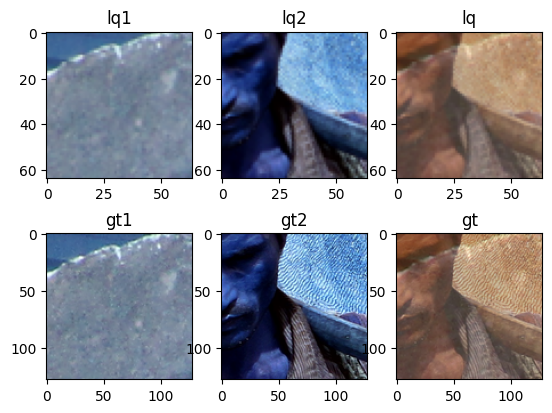

In [26]:
plt.subplot(2,3,1)
plt.title('lq1')
plt.imshow(lq1)
plt.subplot(2,3,2)
plt.title('lq2')
plt.imshow(lq2)
plt.subplot(2,3,3)
plt.title('lq')
plt.imshow(lq)
plt.subplot(2,3,4)
plt.title('gt1')
plt.imshow(gt1)
plt.subplot(2,3,5)
plt.title('gt2')
plt.imshow(gt2)
plt.subplot(2,3,6)
plt.title('gt')
plt.imshow(gt)

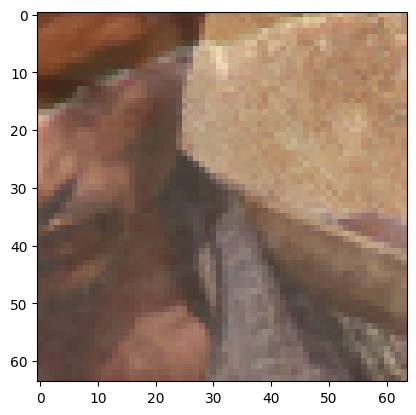

In [27]:
import cv2
im = lq1*0.5+lq2*0.5
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)